In [1]:
from dfbr.eval.simmulation import Sim, create_station_dict, create_event_df
from dfbr.utils.files import get_config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
config = get_config("baseline.yaml")

In [3]:
sim = Sim(
    station_dict= create_station_dict(config["paths"]["stations"], config["paths"]["station_dist_miles"], 0.5),
    event_df= create_event_df(config["paths"]["raw_trips"], config["paths"]["stations"], config["data"]["test_start_date"],  config["data"]["test_end_date"])
)

In [ ]:
sim.run()

df_metrics = pd.DataFrame({
    'Lost Demand': sim.lost_demand,
    'Over Capacity': sim.over_capacity,
    'Forced Returns': sim.forced_returns,
    })

Starting Simulation!
Simulation Complete!


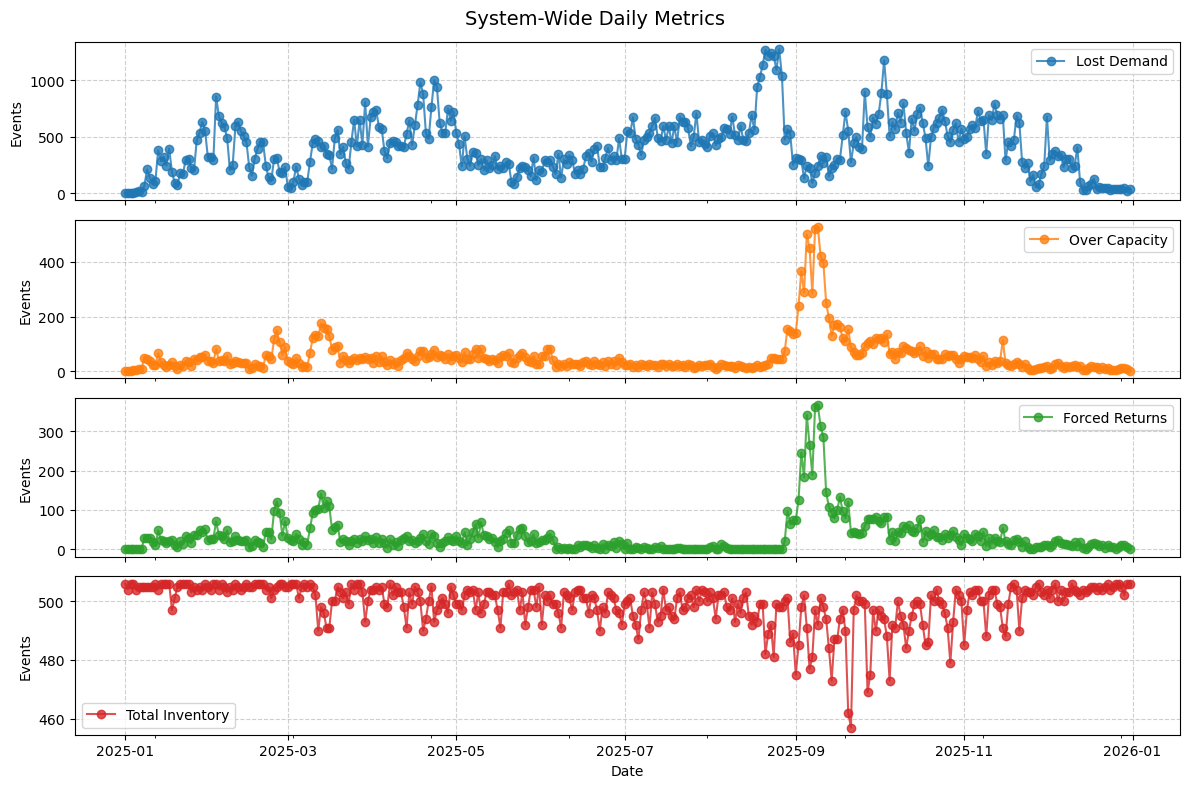

In [5]:
axes = df_metrics.plot(
    kind='line',
    subplots=True, 
    figsize=(12, 8), 
    marker='o', 
    alpha=0.8,
    sharex=True
    )

plt.suptitle("System-Wide Daily Metrics", fontsize=14)

# Loop through each of the 3 axes to add gridlines and Y-labels
for ax in axes:
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylabel("Events")

# The X-label only needs to go on the bottom-most plot
plt.xlabel("Date")

plt.tight_layout()
plt.show()